# Exploratory Data Analysis (EDA)

In [7]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [8]:
df = pd.read_parquet("../data/processed/anime_data_1.parquet")
df.info()

<class 'pandas.DataFrame'>
Index: 5278 entries, 0 to 5307
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   mal_id                 5278 non-null   int64  
 1   title                  5278 non-null   str    
 2   source                 5278 non-null   str    
 3   episodes               5278 non-null   int64  
 4   synopsis               5278 non-null   str    
 5   year                   5278 non-null   int64  
 6   season                 5278 non-null   str    
 7   producers              5278 non-null   object 
 8   genres                 5278 non-null   object 
 9   studios                5278 non-null   object 
 10  demographics           5278 non-null   object 
 11  themes                 5278 non-null   object 
 12  rating                 5278 non-null   str    
 13  sequel                 5278 non-null   bool   
 14  favorites              5278 non-null   int64  
 15  score               

## Sources

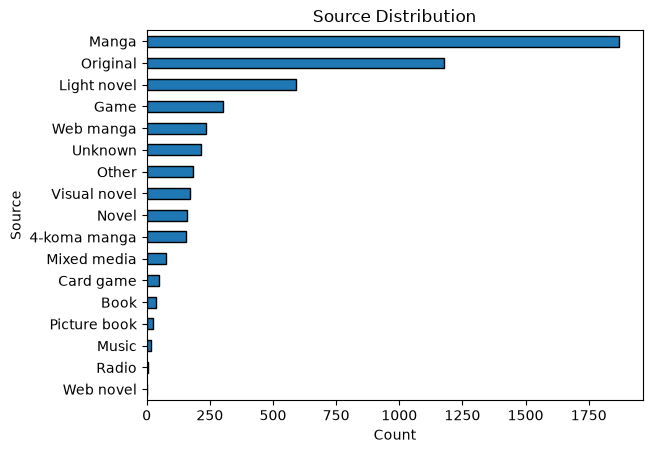

In [9]:
df['source'].value_counts(ascending=True).plot(kind='barh', edgecolor='black')
plt.title('Source Distribution')
plt.xlabel('Count')
plt.ylabel('Source')
plt.show()

## Episode Count

In [10]:
df['episodes'].describe()

count    5278.000000
mean       28.973475
std        71.355984
min         3.000000
25%        12.000000
50%        13.000000
75%        26.000000
max      1818.000000
Name: episodes, dtype: float64

Let's remove the outliers and visualize the rest via a histogram.

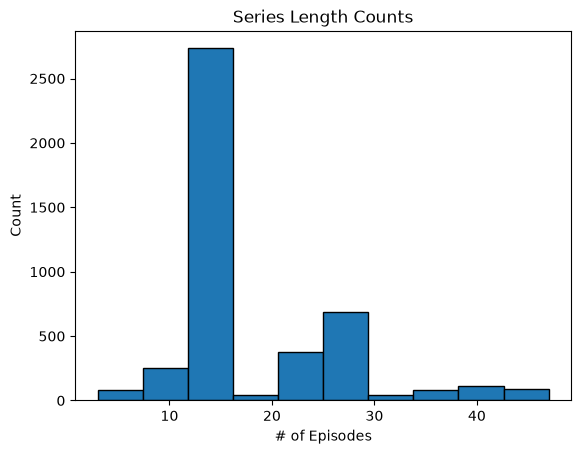

In [11]:
episode_counts = df['episodes']
q1 = episode_counts.quantile(0.25)
q3 = episode_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

episode_counts_cleaned = [x for x in episode_counts if lower_bound <= x <= upper_bound]
plt.hist(episode_counts_cleaned, edgecolor='black')
plt.title('Series Length Counts')
plt.xlabel('# of Episodes')
plt.ylabel('Count')
plt.show()

## Year

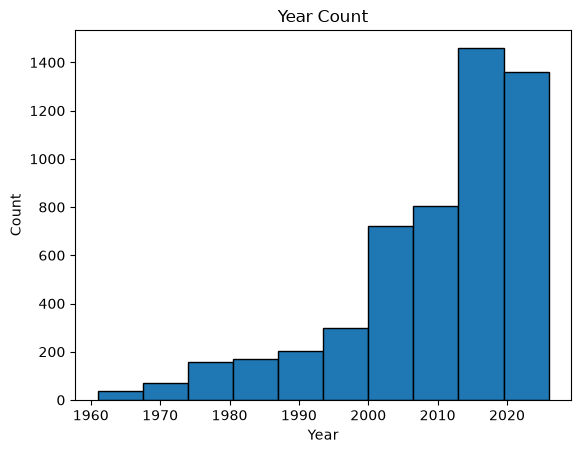

In [12]:
plt.hist(df['year'], edgecolor='black')
plt.title('Year Count')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

## Season

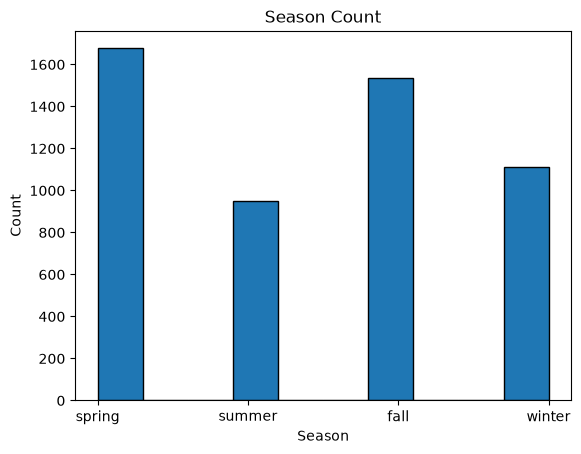

In [13]:
plt.hist(df['season'], edgecolor='black')
plt.title('Season Count')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

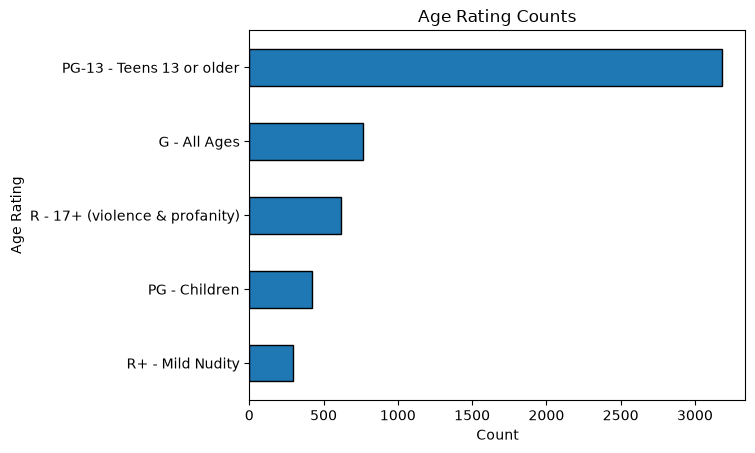

In [14]:
df['rating'].value_counts(ascending=True).plot(kind='barh', edgecolor='black')
plt.title('Age Rating Counts')
plt.xlabel('Count')
plt.ylabel('Age Rating')
plt.show()

## Score

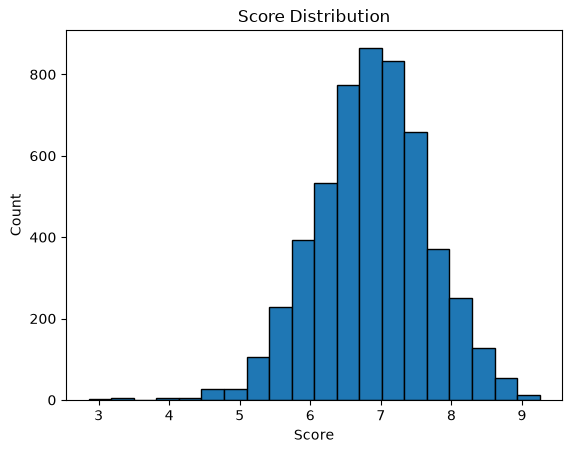

In [48]:
plt.hist(df['score'], edgecolor='black', bins=20)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

## Watching + Completed

In [16]:
df['wc'].describe()

count    5.278000e+03
mean     1.212466e+05
std      2.929328e+05
min      1.760000e+02
25%      2.899000e+03
50%      2.152150e+04
75%      1.004570e+05
max      4.099931e+06
Name: wc, dtype: float64

Let's remove outliers and visualize:

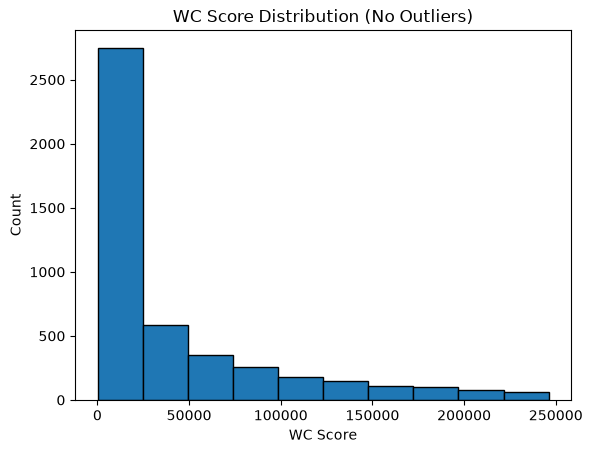

In [17]:
wc_counts = df['wc']
q1 = wc_counts.quantile(0.25)
q3 = wc_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

wc_counts_cleaned = [x for x in wc_counts if lower_bound <= x <= upper_bound]

plt.hist(wc_counts_cleaned, edgecolor='black')
plt.title('WC Score Distribution (No Outliers)')
plt.xlabel('WC Score')
plt.ylabel('Count')
plt.show()

## Dropped

In [18]:
df['dropped'].describe()

count      5278.000000
mean       6739.474991
std       12744.631365
min          61.000000
25%         398.250000
50%        2178.000000
75%        7966.250000
max      247495.000000
Name: dropped, dtype: float64

Remove outliers and visualize:

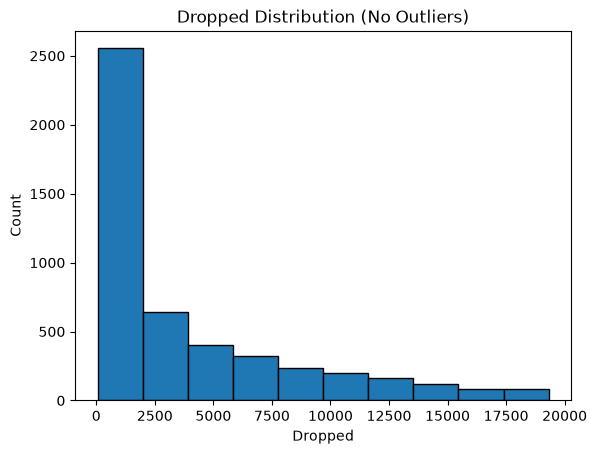

In [19]:
dropped_counts = df['dropped']
q1 = dropped_counts.quantile(0.25)
q3 = dropped_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

dropped_counts_cleaned = [x for x in dropped_counts if lower_bound <= x <= upper_bound]

plt.hist(dropped_counts_cleaned, edgecolor='black')
plt.title('Dropped Distribution (No Outliers)')
plt.xlabel('Dropped')
plt.ylabel('Count')
plt.show()

## Favorites

In [20]:
df['favorites'].describe()

count      5278.000000
mean       2109.566502
std        9964.023791
min           0.000000
25%          13.000000
50%         118.500000
75%         738.500000
max      245130.000000
Name: favorites, dtype: float64

Remove outliers and visualize:

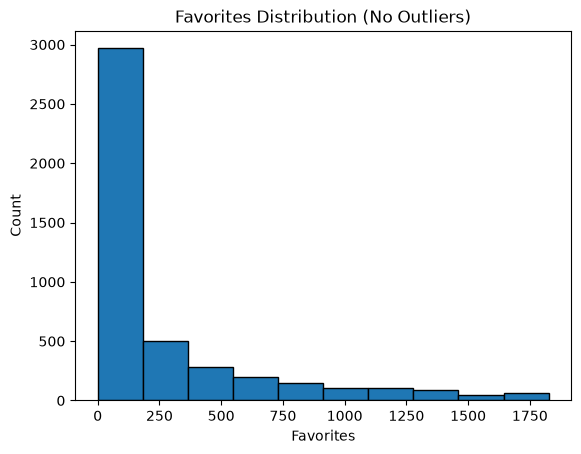

In [21]:
fav_counts = df['favorites']
q1 = fav_counts.quantile(0.25)
q3 = fav_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

fav_counts_cleaned = [x for x in fav_counts if lower_bound <= x <= upper_bound]

plt.hist(fav_counts_cleaned, edgecolor='black')
plt.title('Favorites Distribution (No Outliers)')
plt.xlabel('Favorites')
plt.ylabel('Count')
plt.show()

## Forum Posts

In [22]:
df['forum'].describe()

count    5278.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: forum, dtype: float64

Remove outliers and visualize:

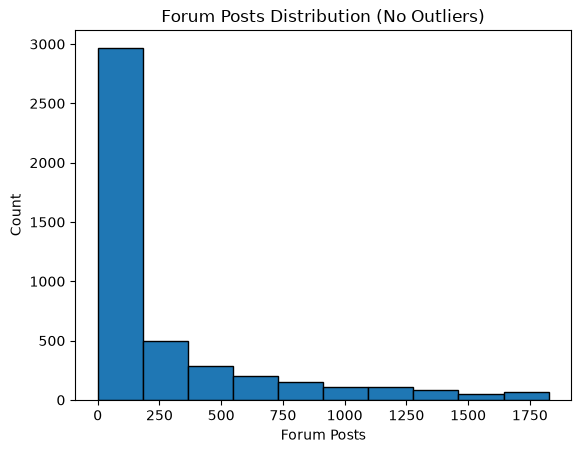

In [23]:
forum_counts = df['forum']
q1 = forum_counts.quantile(0.25)
q3 = forum_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

forum_counts_cleaned = [x for x in forum_counts if lower_bound <= x <= upper_bound]

plt.hist(fav_counts_cleaned, edgecolor='black')
plt.title('Forum Posts Distribution (No Outliers)')
plt.xlabel('Forum Posts')
plt.ylabel('Count')
plt.show()

There seems to be an emerging pattern in the metrics distribution, which is somewhat to be expected: it's normal to see bigger shows have proportionally bigger counts for specific metrics such as favorites, wc score, forum posts, etc.

Other features such as producers, genres, demographics, and themes will be feature-engineered and visualize in the next notebook.

We will primarily be interested with scores, and including other metrics at the end will be decided soon.

## Genre Counts & Score Averages

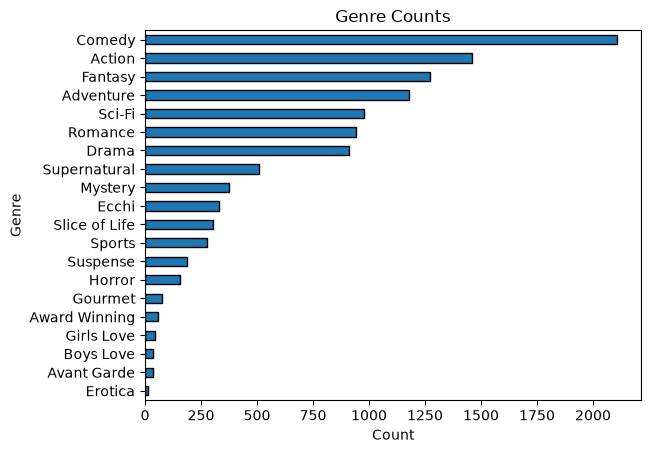

In [24]:
genre_counts = df['genres'].explode().value_counts(ascending=True)
genre_counts.plot(kind='barh', edgecolor='black')
plt.title('Genre Counts')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

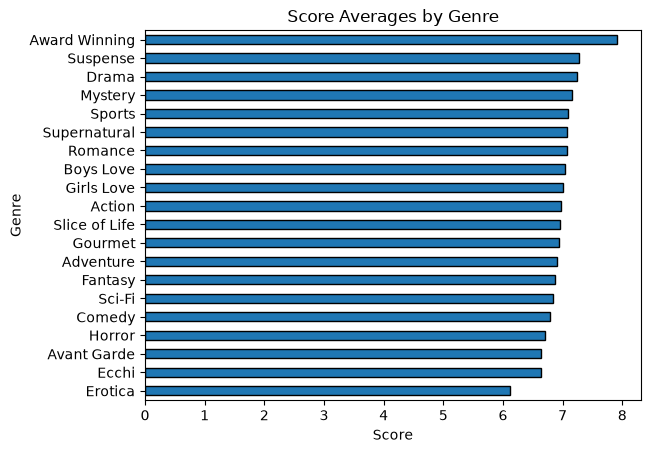

In [25]:
genre_averages = df.explode('genres').groupby('genres')['score'].mean().sort_values()
genre_averages.plot(kind='barh', edgecolor='black')
plt.title('Score Averages by Genre')
plt.xlabel('Score')
plt.ylabel('Genre')
plt.show()

## Theme Counts & Score Averages

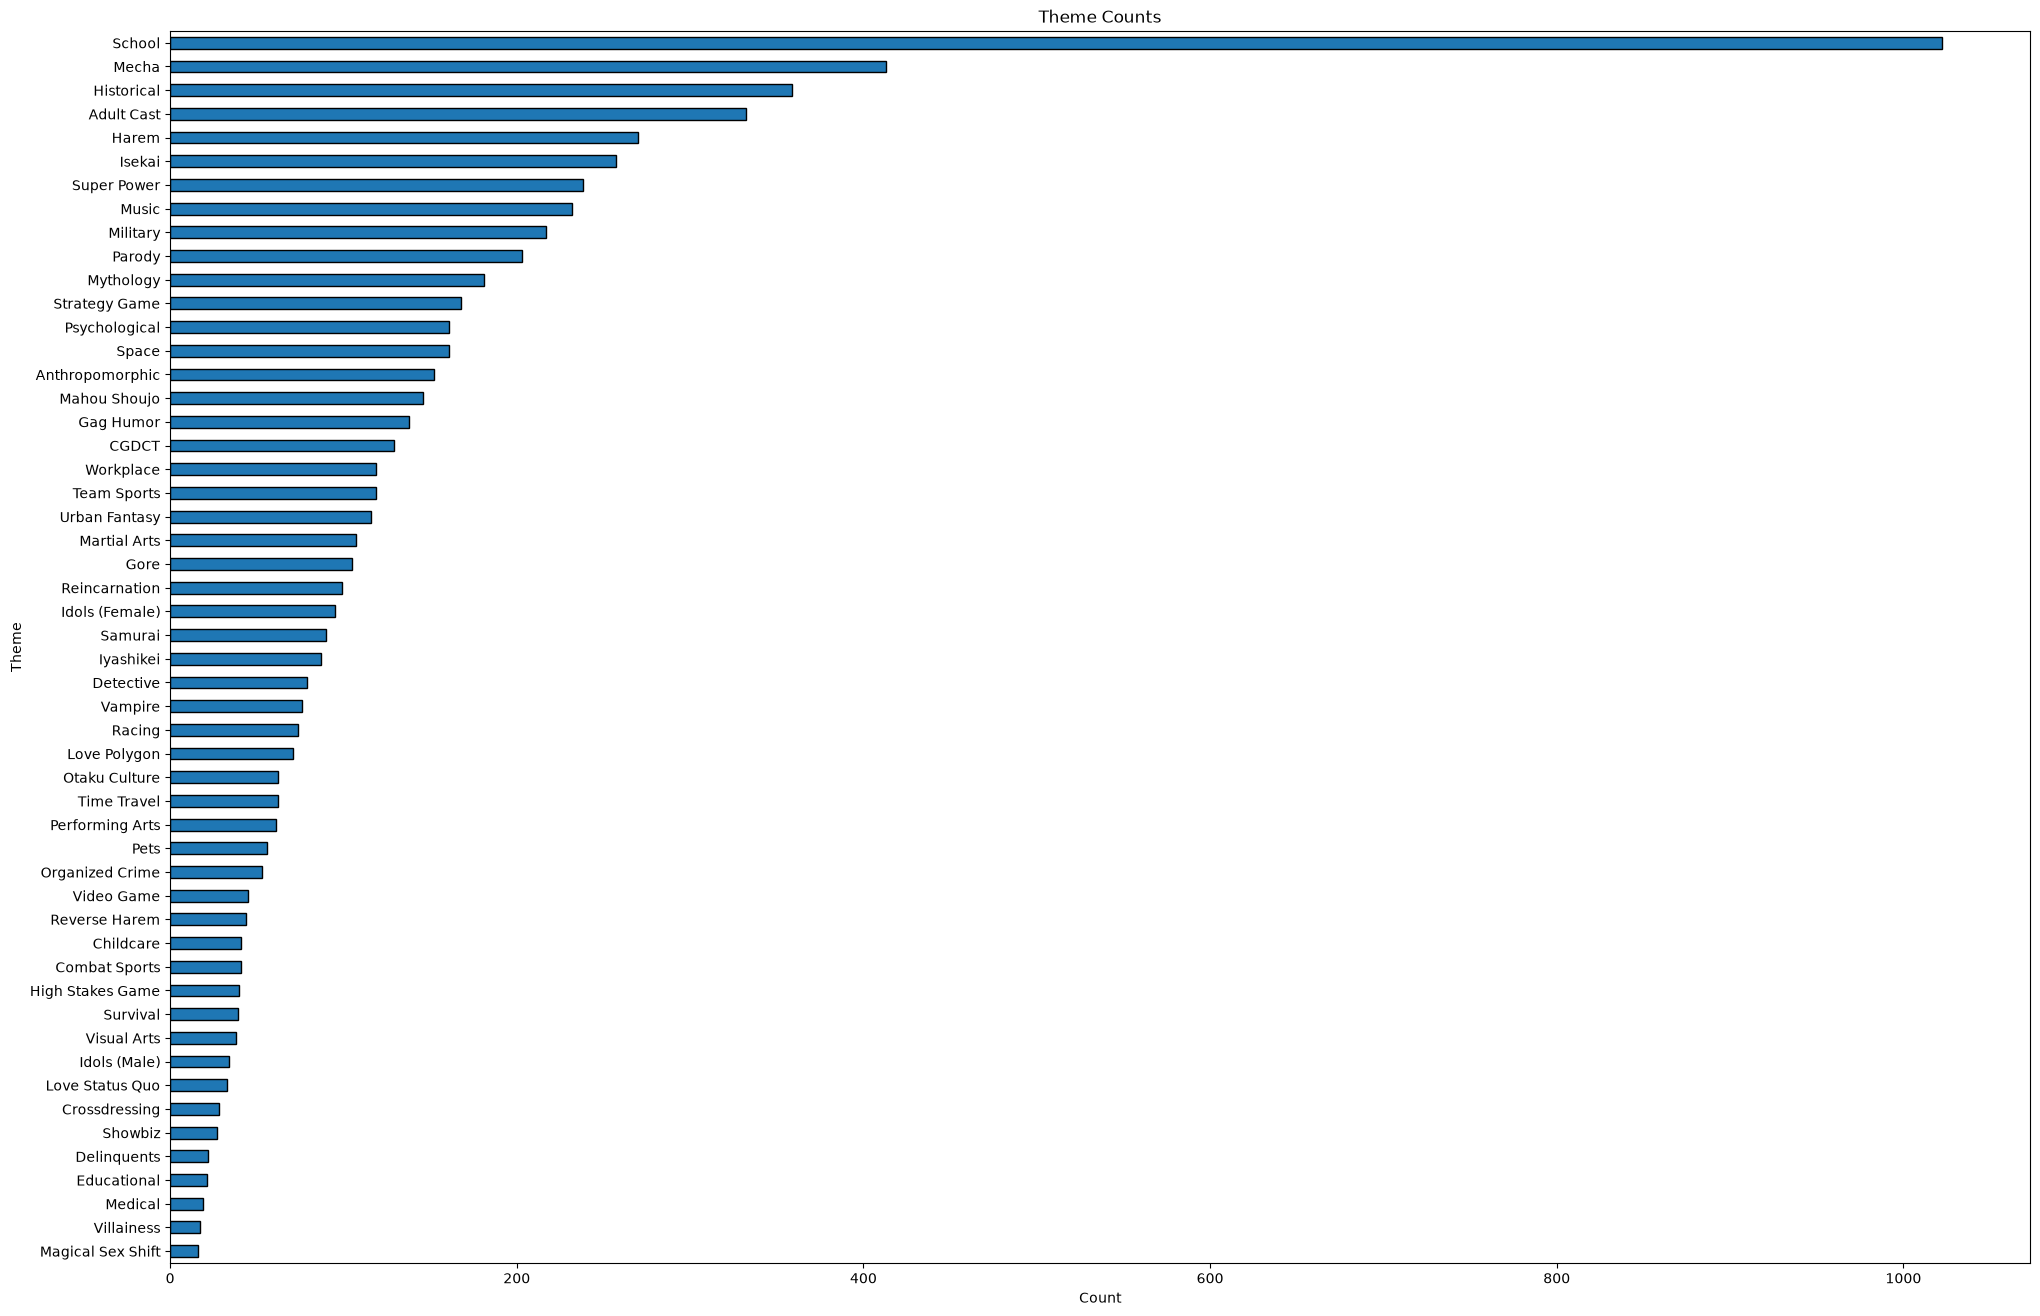

In [26]:
theme_counts = df['themes'].explode().value_counts(ascending=True)
plt.figure(figsize=(24, 16))
theme_counts.plot(kind='barh', edgecolor='black')
plt.title('Theme Counts')
plt.xlabel('Count')
plt.ylabel('Theme')
plt.show()

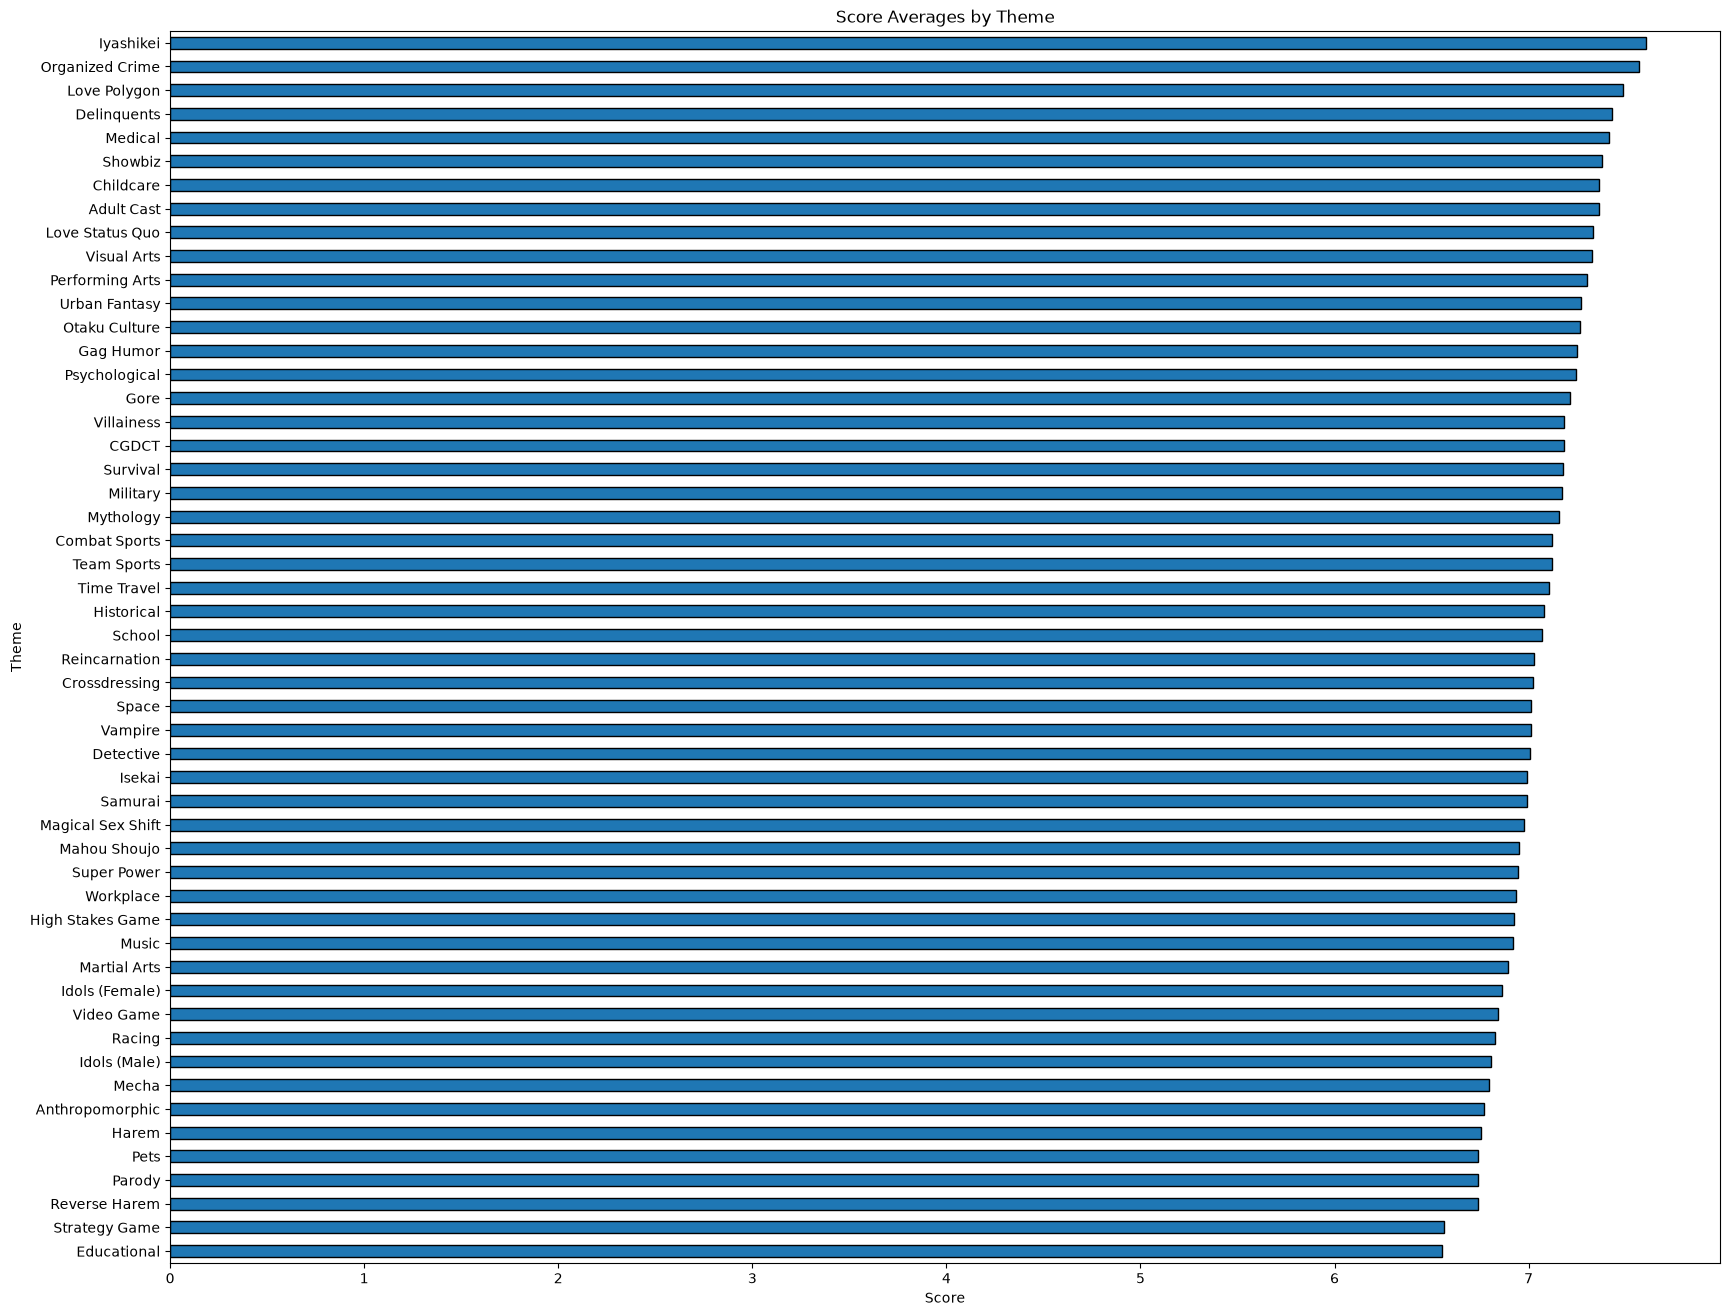

In [27]:
theme_averages = df.explode('themes').groupby('themes')['score'].mean().sort_values()
plt.figure(figsize=(20, 16))
theme_averages.plot(kind='barh', edgecolor='black')
plt.title('Score Averages by Theme')
plt.xlabel('Score')
plt.ylabel('Theme')
plt.show()

## Demographic Counts & Score Averages

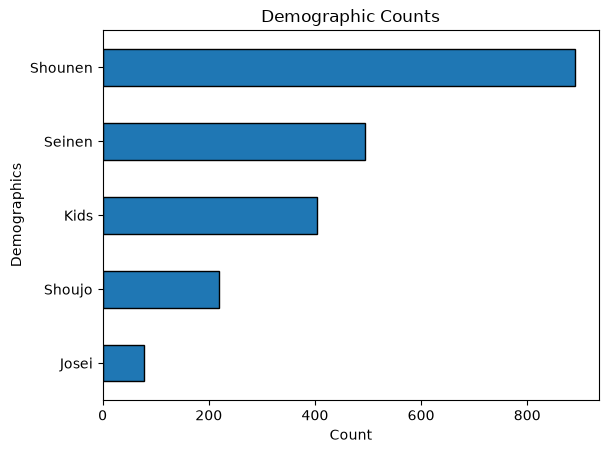

In [28]:
demo_counts = df['demographics'].explode().value_counts(ascending=True)
demo_counts.plot(kind='barh', edgecolor='black')
plt.title('Demographic Counts')
plt.xlabel('Count')
plt.ylabel('Demographics')
plt.show()

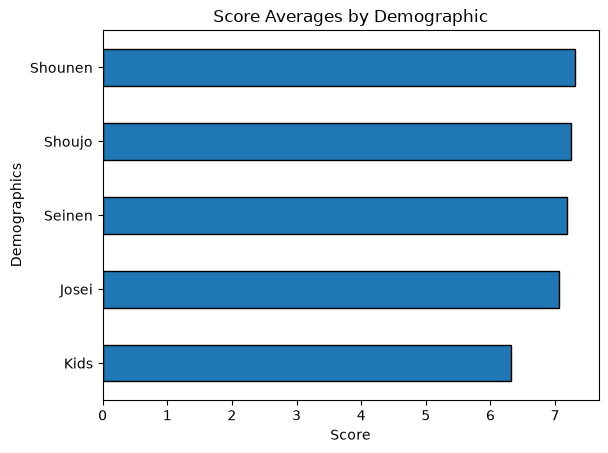

In [29]:
demo_averages = df.explode('demographics').groupby('demographics')['score'].mean().sort_values()
demo_averages.plot(kind='barh', edgecolor='black')
plt.title('Score Averages by Demographic')
plt.xlabel('Score')
plt.ylabel('Demographics')
plt.show()

## Studio Counts & Score Averages

Depending on the number of distinct studios, we will cap at top 30 for both counts and scores.

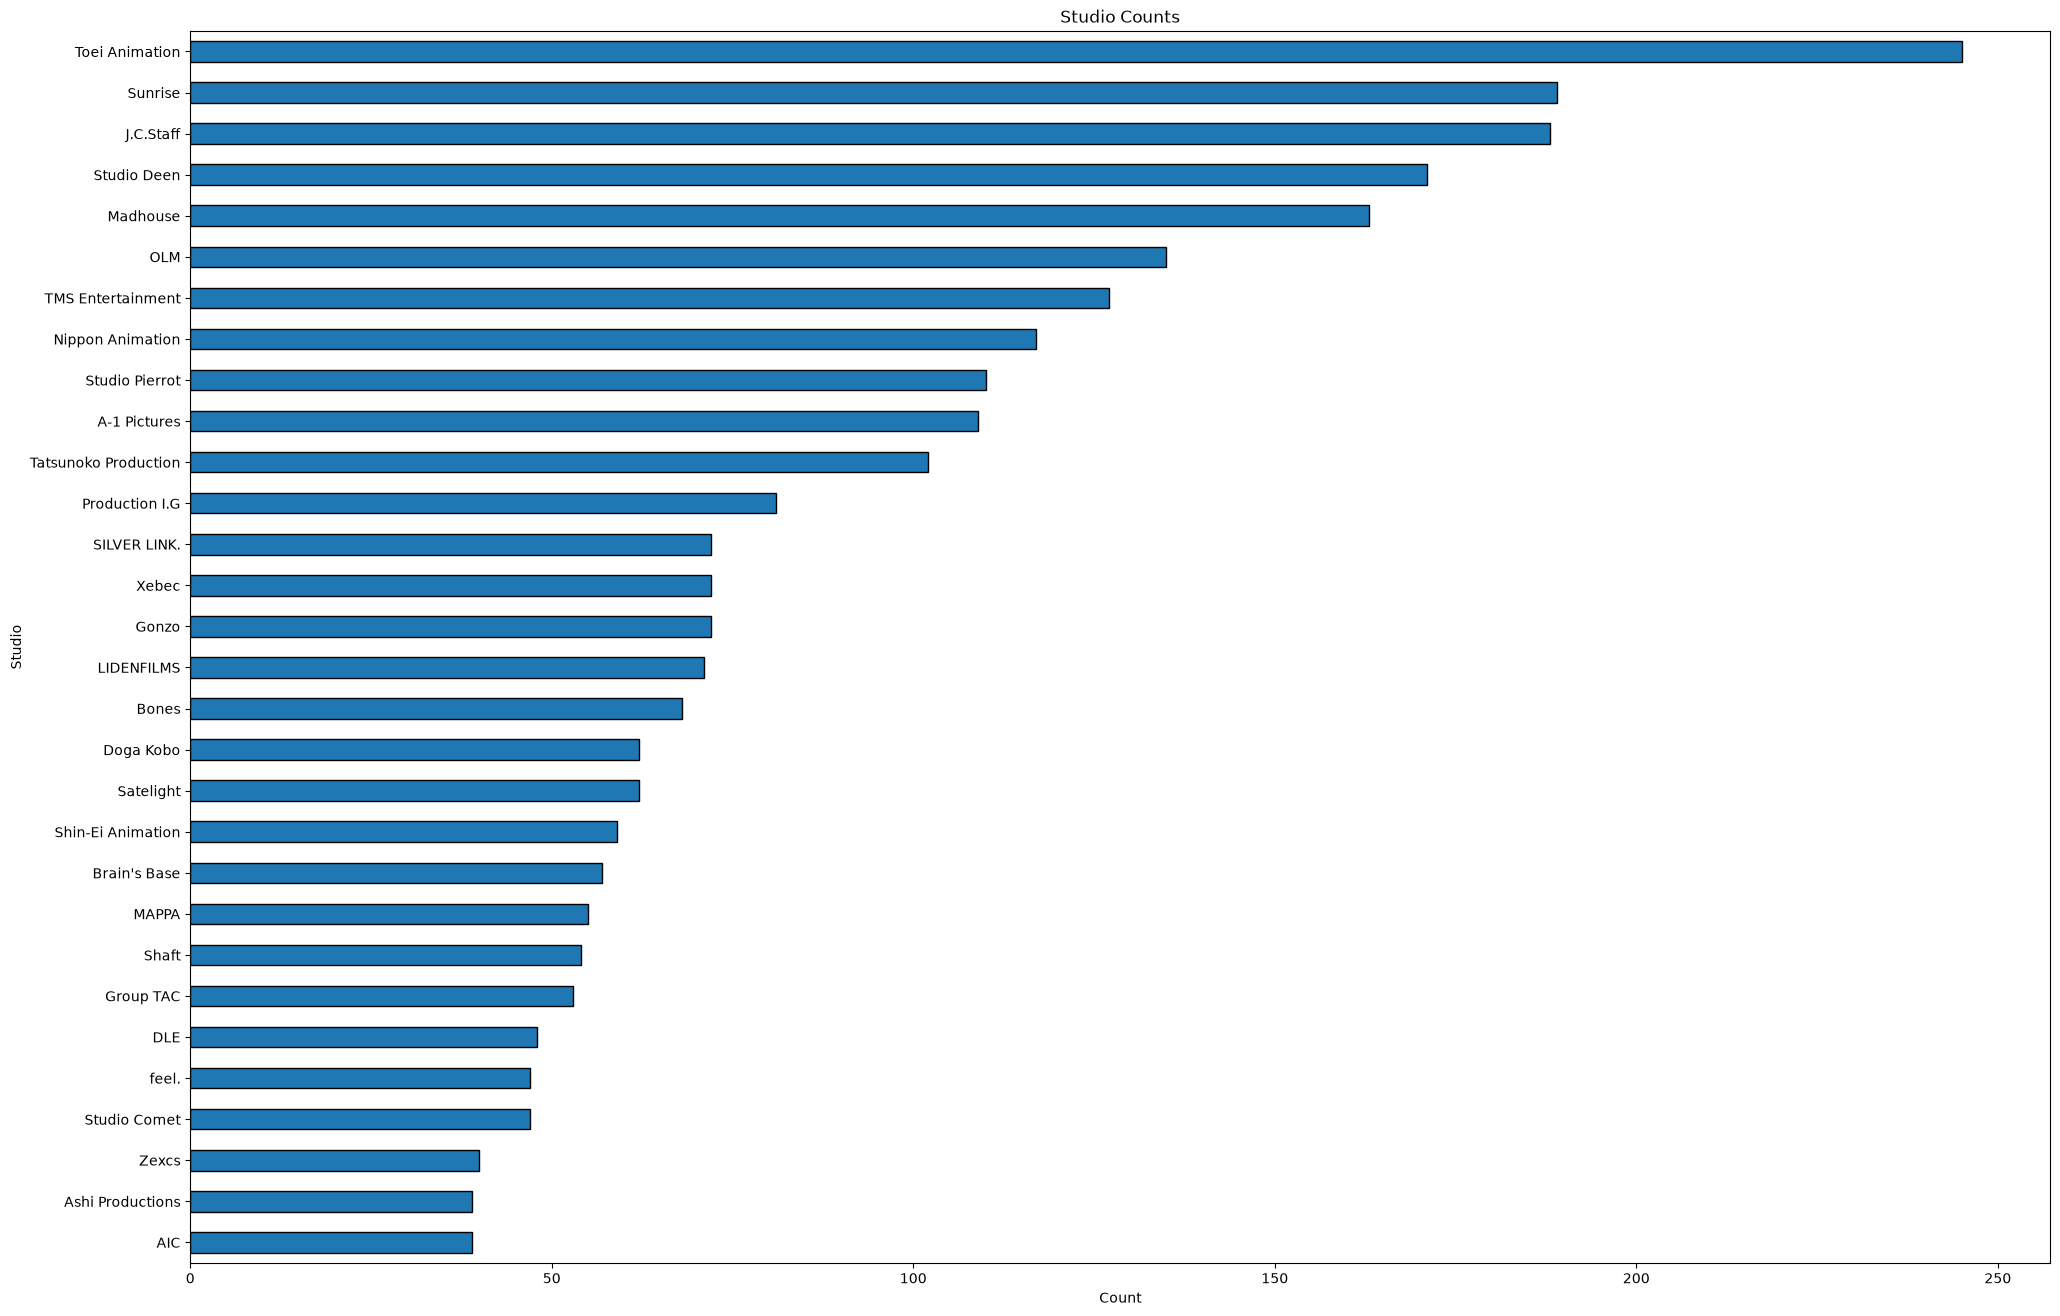

In [30]:
studio_counts = df['studios'].explode().value_counts(ascending=True)
plt.figure(figsize=(24, 16))
studio_counts.tail(30).plot(kind='barh', edgecolor='black')
plt.title('Studio Counts')
plt.xlabel('Count')
plt.ylabel('Studio')
plt.show()

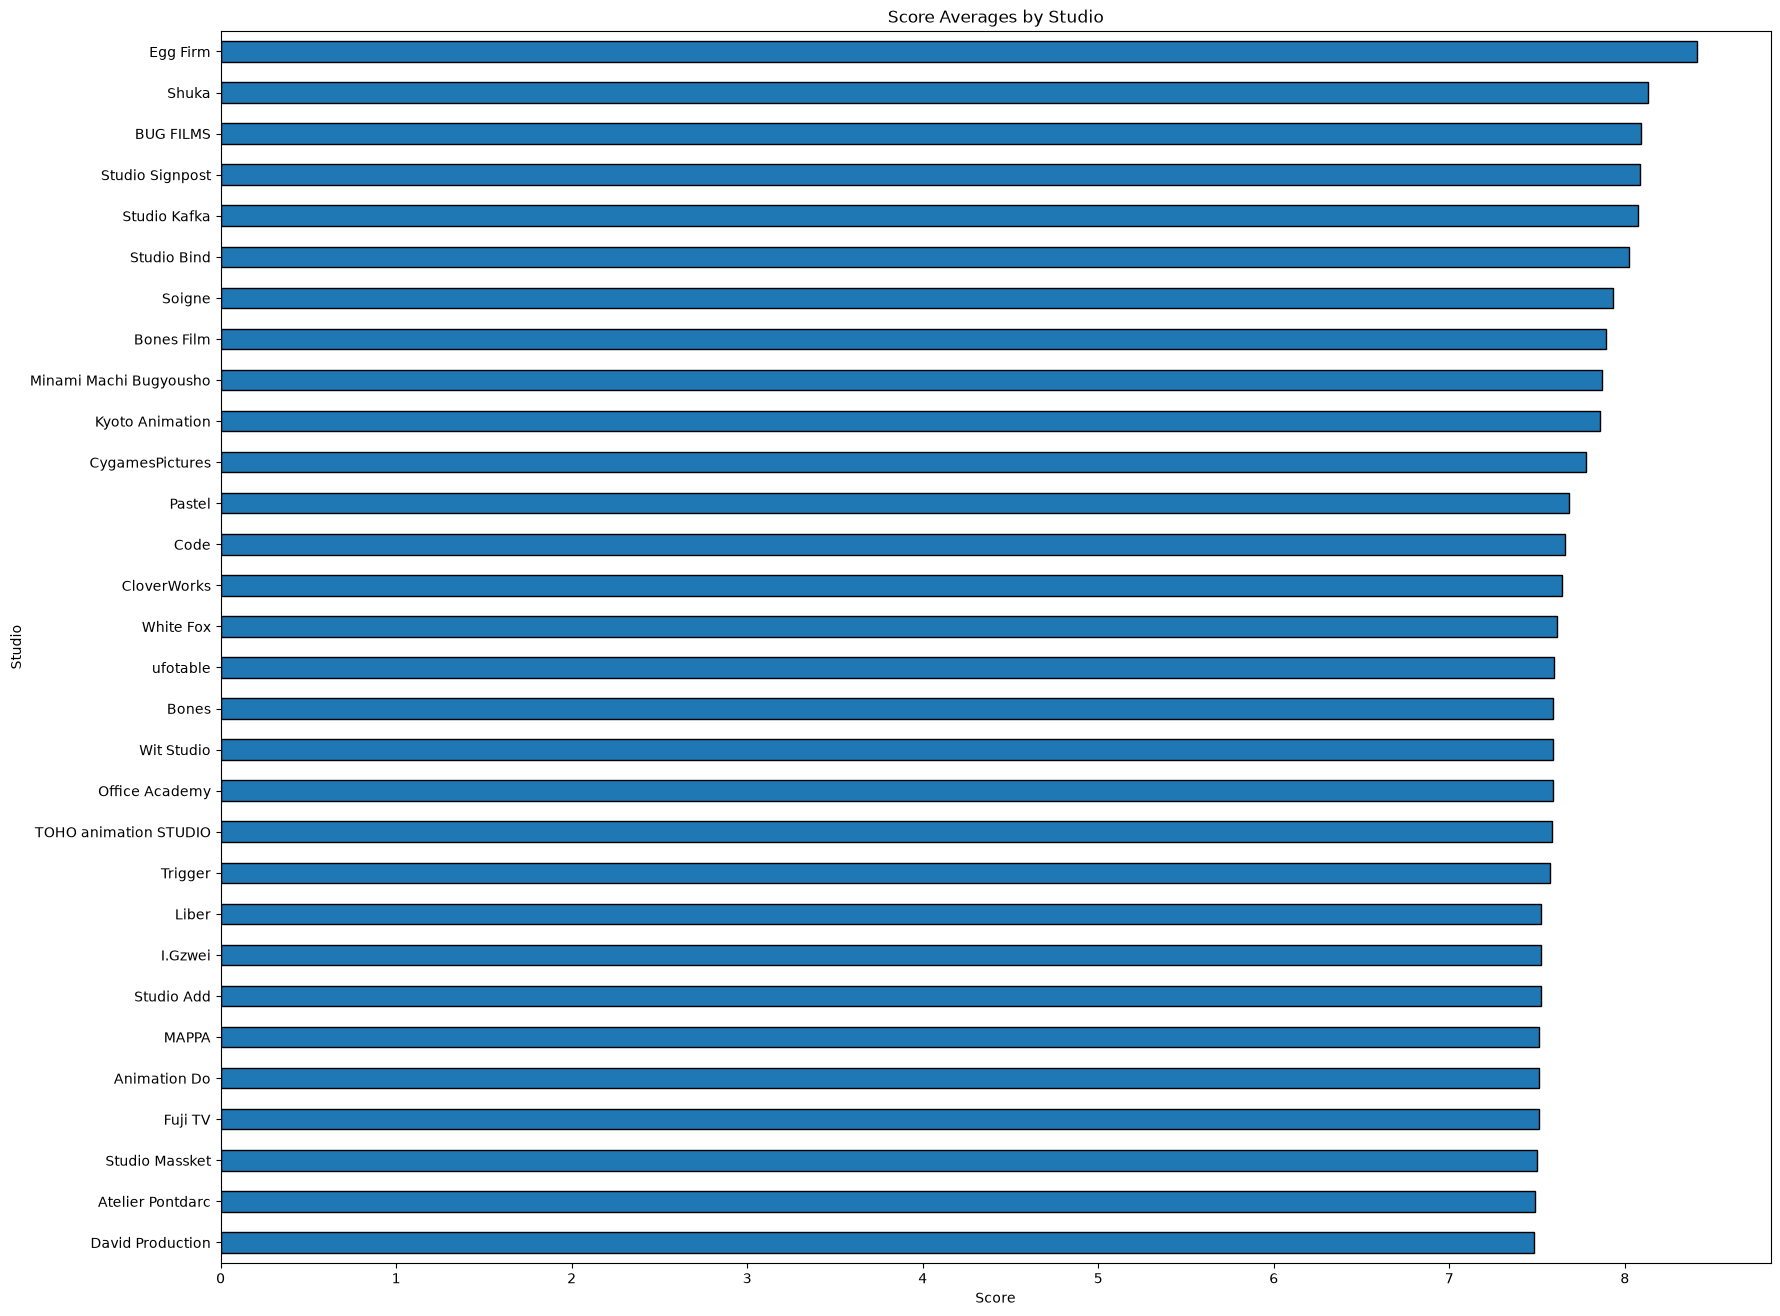

In [31]:
studio_averages = df.explode('studios').groupby('studios')['score'].mean().sort_values()
plt.figure(figsize=(20, 16))
studio_averages.tail(30).plot(kind='barh', edgecolor='black')
plt.title('Score Averages by Studio')
plt.xlabel('Score')
plt.ylabel('Studio')
plt.show()

## Producer Count & Score Averages

We will also cap this to top 30.

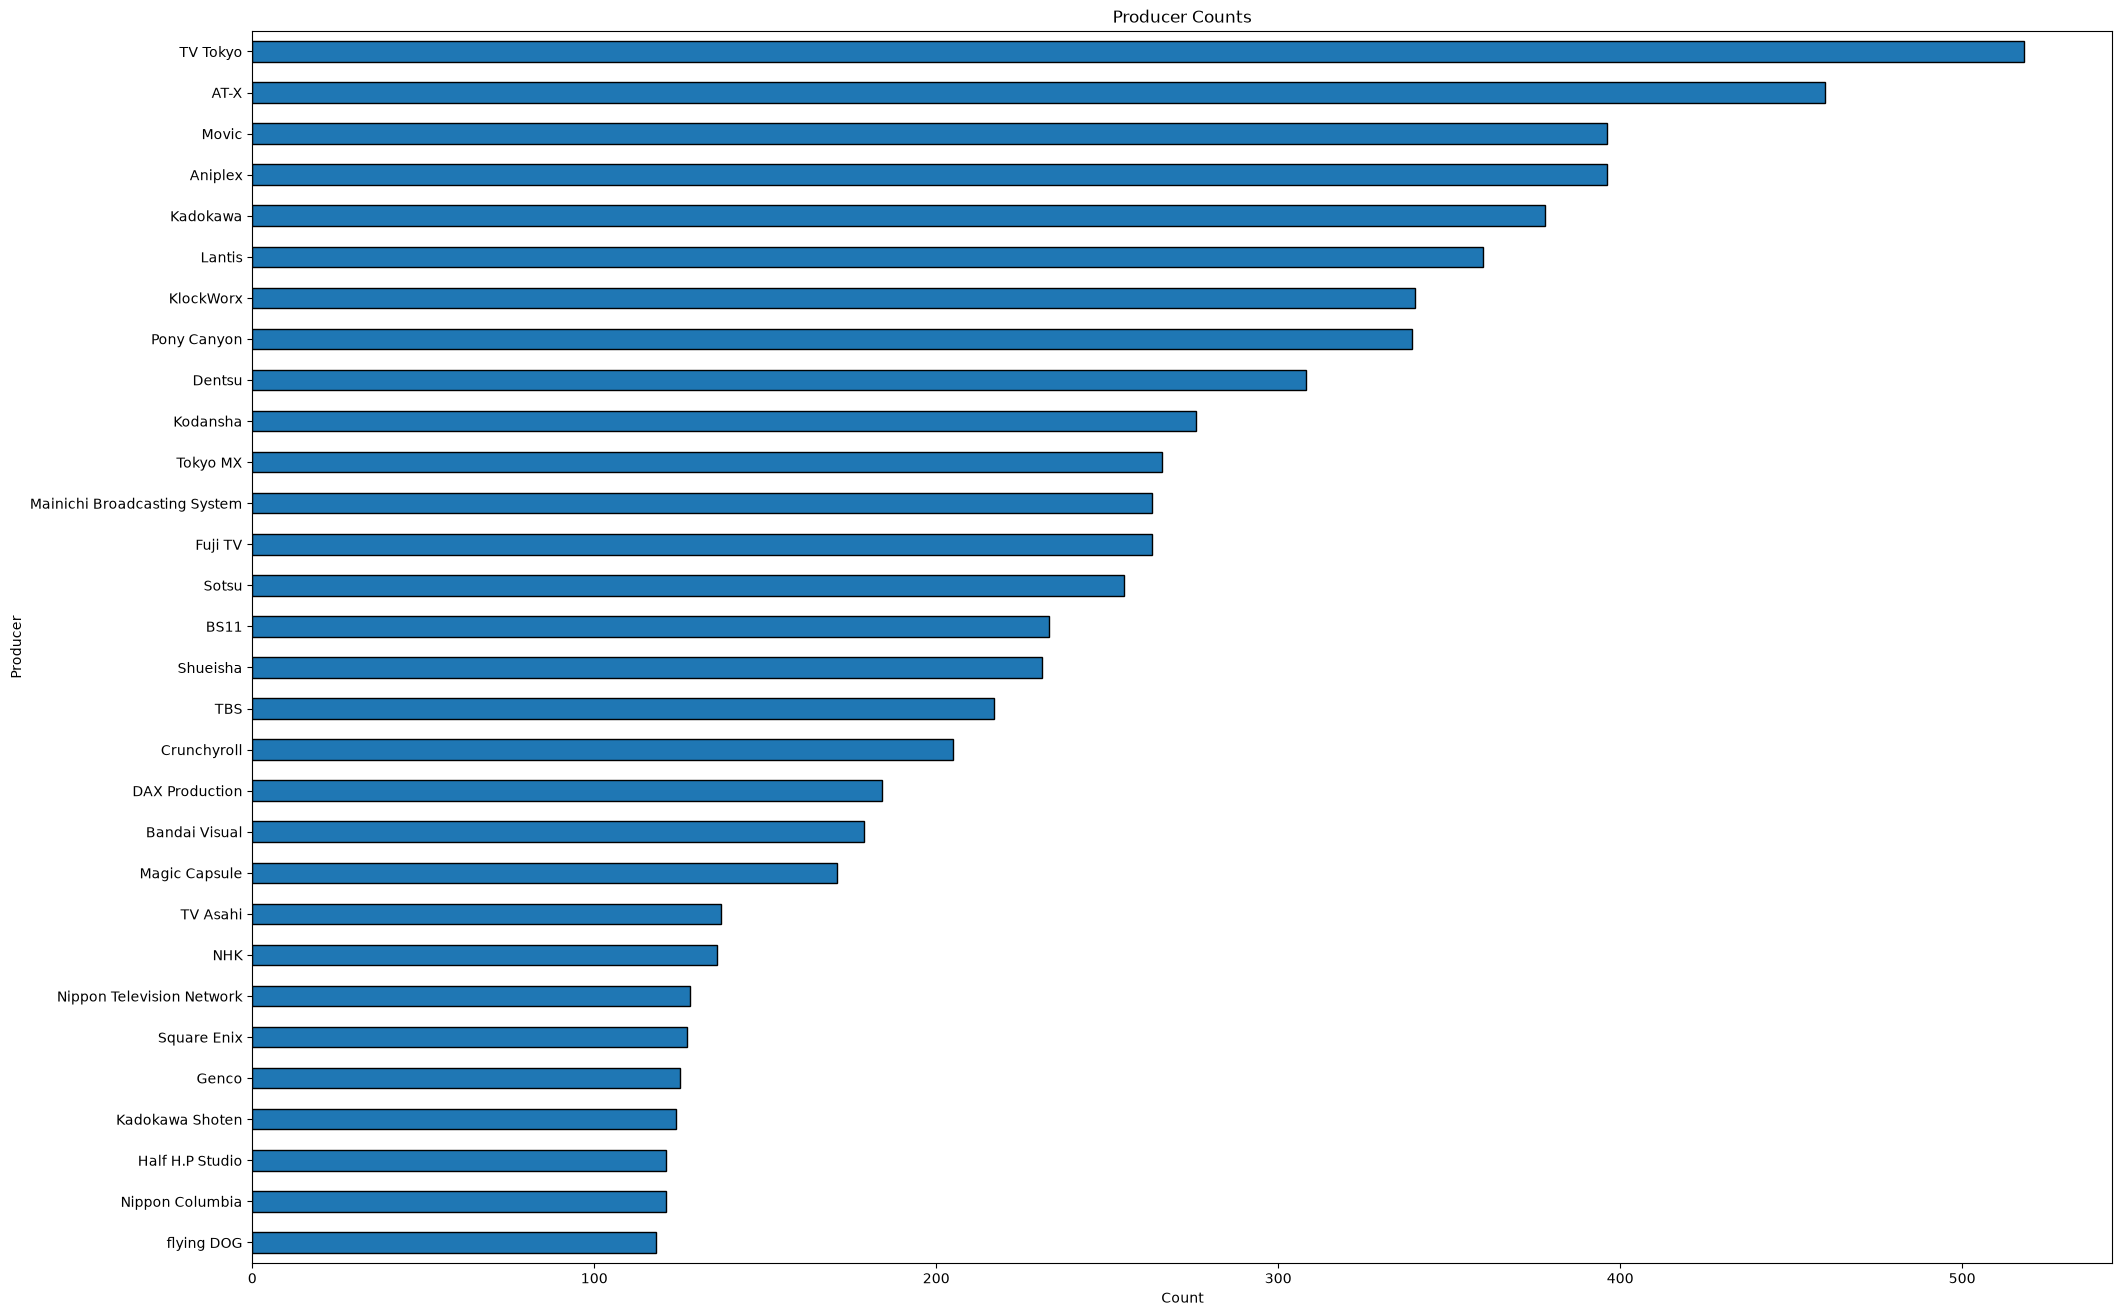

In [32]:
producer_counts = df['producers'].explode().value_counts(ascending=True)
plt.figure(figsize=(24, 16))
producer_counts.tail(30).plot(kind='barh', edgecolor='black')
plt.title('Producer Counts')
plt.xlabel('Count')
plt.ylabel('Producer')
plt.show()

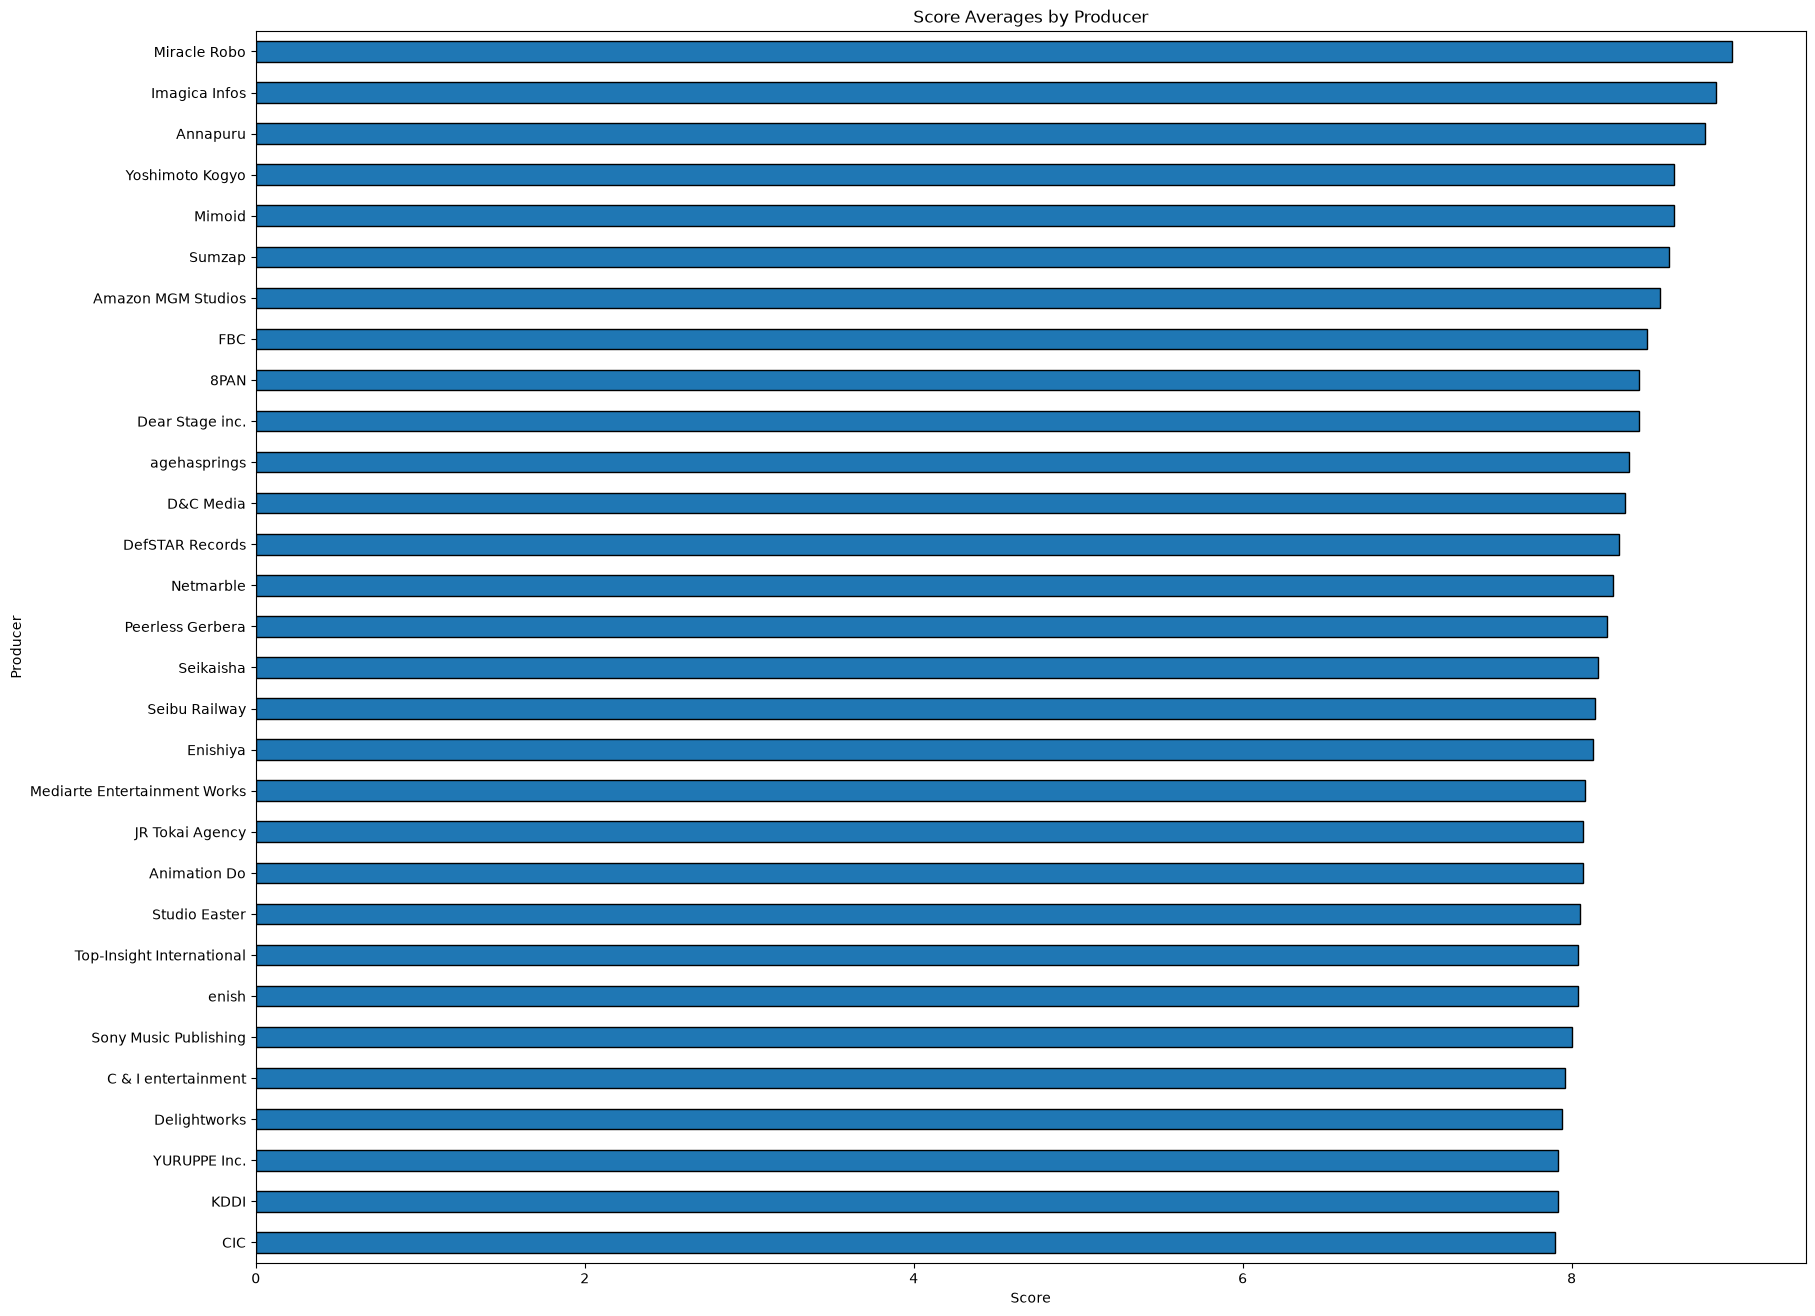

In [33]:
producer_averages = df.explode('producers').groupby('producers')['score'].mean().sort_values()
plt.figure(figsize=(20, 16))
producer_averages.tail(30).plot(kind='barh', edgecolor='black')
plt.title('Score Averages by Producer')
plt.xlabel('Score')
plt.ylabel('Producer')
plt.show()

## Yearly Score Averages

In [34]:
yearly_score = df.groupby(df['year'])['score'].mean()
yearly_score

year
1961    6.090000
1962    5.960000
1963    6.444000
1964    6.230000
1965    6.097778
          ...   
2022    6.954145
2023    7.034450
2024    7.033435
2025    6.952094
2026    7.012982
Name: score, Length: 66, dtype: float64

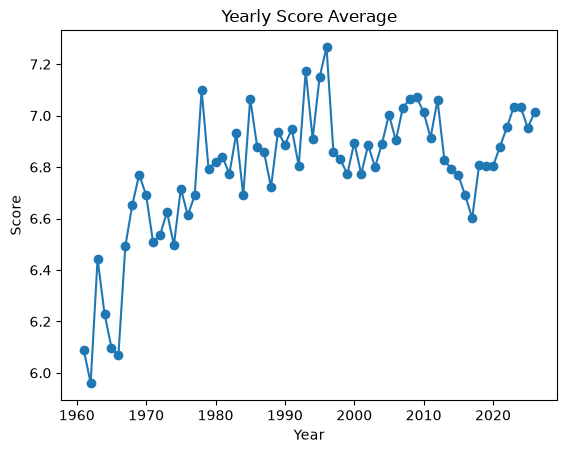

In [35]:
yearly_score.plot(kind='line', marker='o')

plt.title("Yearly Score Average")
plt.xlabel("Year")
plt.ylabel("Score")
plt.grid=True

plt.show()

## Season Score Averages

In [36]:
season_score = df.groupby(df['season'])['score'].mean()
season_score

season
fall      6.917124
spring    6.885549
summer    6.833172
winter    6.840413
Name: score, dtype: float64

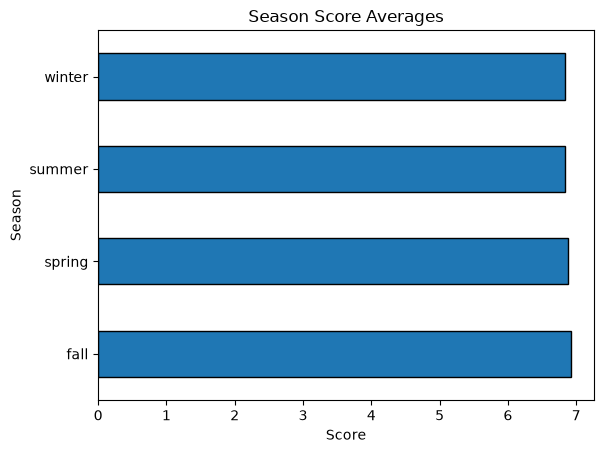

In [37]:
season_score.plot(kind='barh', edgecolor='black')
plt.title('Season Score Averages')
plt.xlabel('Score')
plt.ylabel('Season')
plt.show()

## Age Rating Averages

In [38]:
rating_score = df.groupby(df['rating'])['score'].mean()
rating_score

rating
G - All Ages                      6.551877
PG - Children                     6.483957
PG-13 - Teens 13 or older         6.945198
R - 17+ (violence & profanity)    7.289887
R+ - Mild Nudity                  6.661815
Name: score, dtype: float64

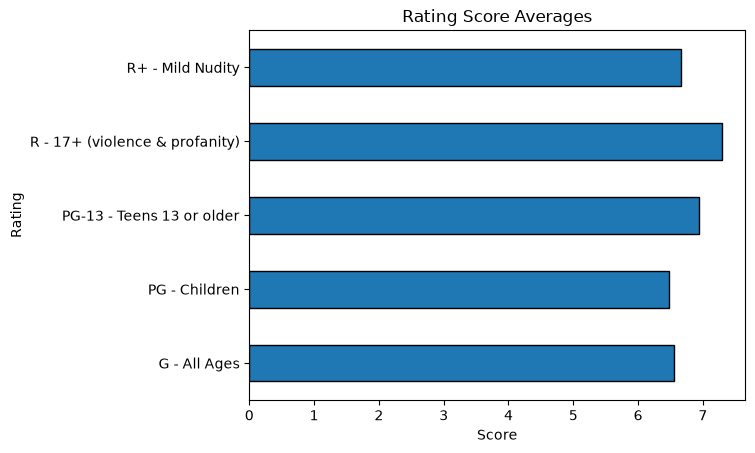

In [39]:
rating_score.plot(kind='barh', edgecolor='black')
plt.title('Rating Score Averages')
plt.xlabel('Score')
plt.ylabel('Rating')
plt.show()

## Sequel vs. Non-sequel

In [40]:
sequel_score = df.groupby(df['sequel'])['score'].mean()
sequel_score

sequel
False    6.795835
True     7.102478
Name: score, dtype: float64

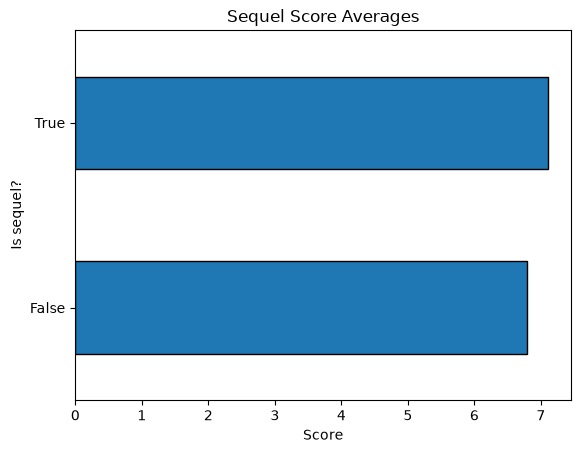

In [41]:
sequel_score.plot(kind='barh', edgecolor='black')
plt.title('Sequel Score Averages')
plt.xlabel('Score')
plt.ylabel('Is sequel?')
plt.show()

## Score vs. WC Scatterplot

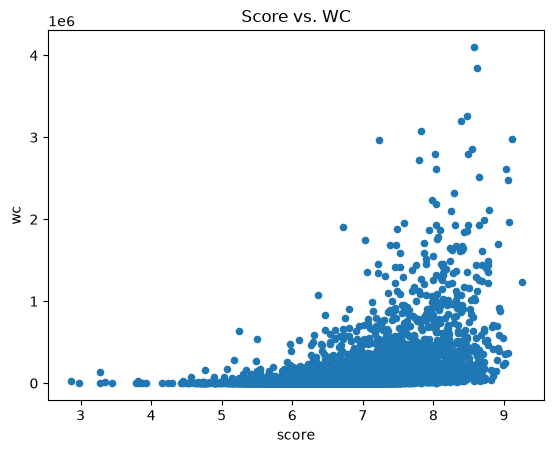

In [42]:
df.plot.scatter(x='score', y='wc', title="Score vs. WC")
plt.show()

## Scores vs. Favorites Scatterplot

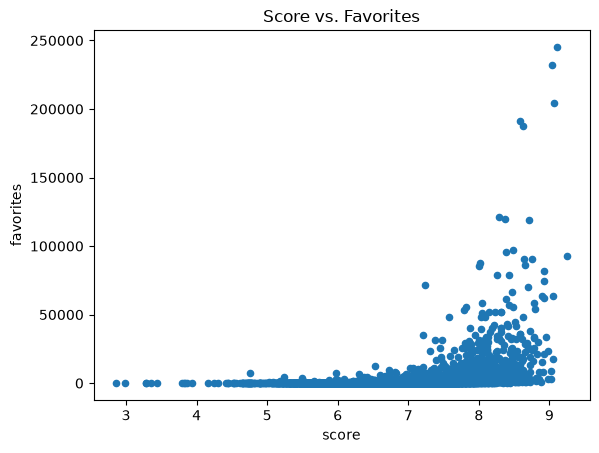

In [43]:
df.plot.scatter(x='score', y='favorites', title="Score vs. Favorites")
plt.show()

## Scores vs. Dropped Scatterplot

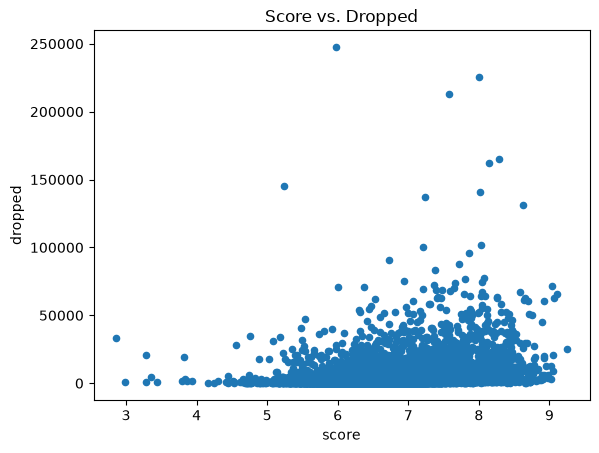

In [44]:
df.plot.scatter(x='score', y='dropped', title="Score vs. Dropped")
plt.show()

## Score vs. Forum Posts

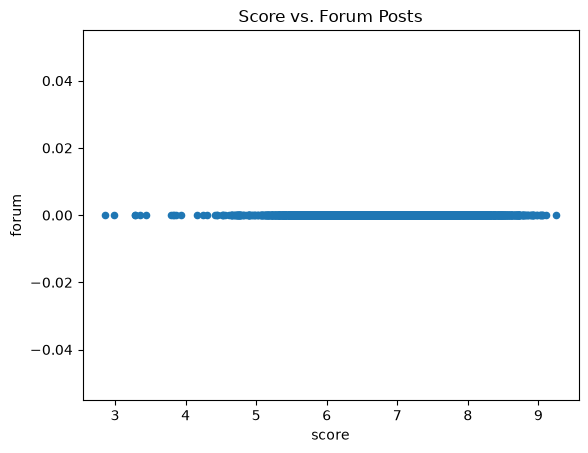

In [45]:
df.plot.scatter(x='score', y='forum', title="Score vs. Forum Posts")
plt.show()

## Metric Correlations

In [46]:
temp_df = df[['score', 'wc', 'favorites', 'dropped', 'forum']]
correlation_matrix = temp_df.corr()
correlation_matrix

,score,wc,favorites,dropped,forum
score,1.000000,0.414572,0.329901,0.246815,NaN
wc,0.414572,1.000000,0.777676,0.706682,NaN
favorites,0.329901,0.777676,1.000000,0.560717,NaN
dropped,0.246815,0.706682,0.560717,1.000000,NaN
forum,NaN,NaN,NaN,NaN,NaN


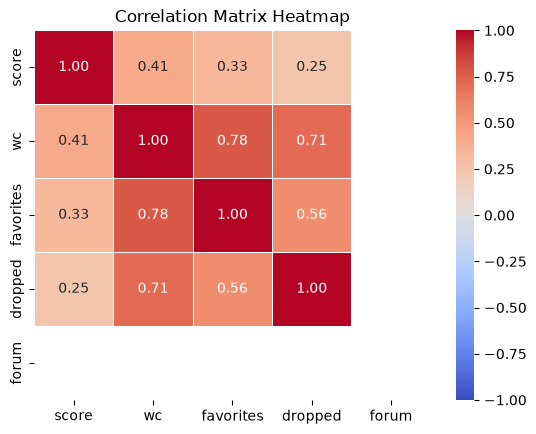

In [47]:
sns.heatmap(
    correlation_matrix,
    annot=True,  # Show numeric values inside keys
    cmap="coolwarm",  # Diverging colormap (blue = negative, red = positive)
    vmin=-1,
    vmax=1,  # Force scale from -1 to 1
    center=0,  # Center color mapping at 0
    fmt=".2f",  # Format numbers to 2 decimal places
    linewidths=0.5,  # Add subtle lines between cells
)

plt.title("Correlation Matrix Heatmap")
plt.show()